In [52]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, sphereMask, bipyramidMask, saveData, kernelPad
importlib.reload(sys.modules['Helpers'])
importlib.reload(sys.modules['Helpers.bipyramidMask'])
importlib.reload(sys.modules['Helpers'])

import math
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.fft as fft
import torch.nn.functional as F
from scipy.ndimage import convolve
import stackview
from scipy.ndimage import zoom
from matplotlib.path import Path
from scipy.ndimage import rotate
import ipywidgets as widgets
from IPython.display import display
import napari
from magicgui import magicgui


import matplotlib.pyplot as plt
import napari
from qtpy.QtWidgets import QSlider, QVBoxLayout, QWidget, QLabel
from qtpy.QtCore import Qt
from skimage.feature import peak_local_max
from skimage.feature import peak_local_max as pk
import numpy as np
from scipy.ndimage.measurements import center_of_mass, label
from scipy.ndimage.interpolation import zoom
from skimage.transform import resize
import h5py

from sklearn.preprocessing import normalize
from skimage.feature import peak_local_max
from scipy.signal import fftconvolve
from skimage.feature import peak_local_max as pk

C:\Users\Lab User\AppData\Local\Temp\ipykernel_3604\1138071961.py:38: DeprecationWarning: Please import `center_of_mass` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.measurements import center_of_mass, label
C:\Users\Lab User\AppData\Local\Temp\ipykernel_3604\1138071961.py:38: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.measurements import center_of_mass, label
C:\Users\Lab User\AppData\Local\Temp\ipykernel_3604\1138071961.py:39: DeprecationWarning: Please import `zoom` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import zoom


In [53]:
# Load downscaled data
name = 'pCycle2s3'
path = os.path.join(os.path.dirname(parent),'Data')
data = 1 - loadData(location=path, fileName=name+'.hdf5')

In [54]:
# Determine current device
device = torch.cuda.get_device_name()

if device == 'NVIDIA RTX A2000 12GB':
    client = 'Desktop'; cuts = 2
if device == 'NVIDIA RTX 4000 Ada Generation':
    client = 'Server';  cuts = 1

print(f'Identified {client}: {device}')

Identified Desktop: NVIDIA RTX A2000 12GB


In [55]:
# Display data dims
r,c,z = data.shape
print(f'Data dims: {r,c,z}')

# Crop to proper data dims
cropData = data[:,:908,:]; r,c,z = cropData.shape
print(f'Crop dims: {r,c,z}')

# Check size validity for desktop
if client == 'Desktop':
    assert r % 2 == 1, f"Row dim fail: {r} % 2 = {r % 2} | Goal: 1"
    assert c % 4 == 0, f"Col dim fail: {c} % 4 = {c % 4} | Goal: 0"
    assert z % 4 == 0, f"Zed dim fail: {z} % 4 = {z % 4} | Goal: 0"

print('Valid size')


Data dims: (839, 911, 448)
Crop dims: (839, 908, 448)
Valid size


In [56]:
napData = np.swapaxes(cropData,axis1=2,axis2=0) # (r,c,z) -> (z,c,r)

viewer = napari.Viewer()
viewer.add_image(napData)

rectLayer = viewer.add_shapes(ndim=3, name='roi_box', shape_type='rectangle')
zBounds = {'lower': None, 'upper': None}

@magicgui(call_button='Set Lower Bound')
def set_lower():
    zBounds['lower'] = viewer.dims.current_step[0]

@magicgui(call_button='Set Upper Bound')
def set_upper():
    zBounds['upper'] = viewer.dims.current_step[0]

viewer.window.add_dock_widget(set_lower, area='right')
viewer.window.add_dock_widget(set_upper, area='right')

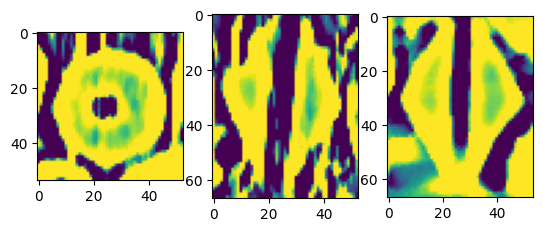

In [69]:
rect    = rectLayer.data[0].astype(int)
zValues = zBounds.values()

particle = napData[min(zValues)  :max(zValues),
                      min(rect[:,1]):max(rect[:,1]),
                      min(rect[:,2]):max(rect[:,2])]
pSz = particle.shape

fig,axs = plt.subplots(1,3)
axs[0].imshow(particle[pSz[0]//2,:,:])
axs[1].imshow(particle[:,pSz[1]//2,:])
axs[2].imshow(particle[:,:,pSz[2]//2])

stackview.orthogonal(zoom(particle,4), continuous_update=True, colormap='viridis')

In [70]:
# Create sphere conv mask
kernel = sphereMask(diameter=67, pad=2, scale=.6)
kP = kernel.shape[0]//2+1

assert kernel.shape[0] % 2 == 1, f'Kernel must be odd: {kernel.shape}'
assert kP % 2 == 1,              f'Kernel padding must be odd: kP={kP}'

viewer = napari.Viewer()
viewer.add_image(particle, name='particle', colormap='viridis')
viewer.add_image(kernel,   name='kernel',   colormap='gray',   opacity=0.15)

<Image layer 'kernel' at 0x20fc00f4700>

In [73]:
# Create bipyramid conv mask
diamPyr = 22
heightPyr = 40
kernel = bipyramidMask(n=8, R=diamPyr, H=heightPyr, hr=5, pad=0, scale=1)
kP = kernel.shape[0]//2 + 1

# Check for center point
assert kernel.shape[0] % 2 == 1, f'Kernel must be odd: {kernel.shape}'
assert kP % 2 == 1,             f'Kernel padding must be odd: kP={kP}'

# particle is assumed to be a 3D stack: (Z, Y, X)
n_layers = min(kernel.shape[2], particle.shape[0])

def showKernel(rot_z, rot_y, rot_x, alpha, layer):
    # Rotate kernel
    k = kernel.copy()
    k = rotate(k, rot_z, axes=(0,1), reshape=False)  # rotate in r,c plane
    k = rotate(k, rot_y, axes=(0,2), reshape=False)  # rotate in r,z plane
    k = rotate(k, rot_x, axes=(1,2), reshape=False)  # rotate in c,z plane
    
    # Visualize chosen slice against particle stack
    plt.figure(figsize=(8,8))
    plt.imshow(particle[layer])
    plt.imshow(k[:, :, layer], alpha=alpha, cmap='grey')
    plt.title(f'Layer {layer}/{n_layers-1}')
    plt.show()

widgets.interact(
    showKernel,
    rot_z = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot Z'),
    rot_y = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot Y'),
    rot_x = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot X'),
    alpha = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.3, description='Alpha'),
    layer = widgets.IntSlider(min=0, max=n_layers-1, step=1, value=n_layers//2, description='Layer'),
);

interactive(children=(IntSlider(value=0, description='Rot Z', max=180, min=-180), IntSlider(value=0, descripti…

In [59]:
# Break data into chunks, padding each

# Split data
upper = cropData[:,:,   int(z/2)-kP: ] # U
lower = cropData[:,:, 0:int(z/2)+kP  ] # L

# Keep 2 split if server
if client == 'Server':
    kChunks = [lower,upper]

# Split into 4 if desktop
if client == 'Desktop':
    ul,uu = upper[:, :int(c/2)+kP ,:], upper[:, int(c/2)-kP: ,:]
    ll,lu = lower[:, :int(c/2)+kP ,:], lower[:, int(c/2)-kP: ,:]
    kChunks = [ll,ul,lu,uu]

# Pad chunks
pChunks = [np.pad(chunk,pad_width=kP) for chunk in kChunks]

In [60]:
# Pad kernel to data chunk dimensions
expansionPadding = [(chunkDim-kernelDim)//2 for chunkDim, kernelDim in zip(pChunks[0].shape, kernel.shape)]
pKernel          = np.pad(kernel, pad_width=((expansionPadding[0],expansionPadding[0]),
                                             (expansionPadding[1],expansionPadding[1]),
                                             (expansionPadding[2],expansionPadding[2])))

# Confirm sizes are equal
print(f'Padded chunk size:  {pChunks[0].shape}')
print(f'Padded kernel size: {pKernel.shape}')
assert pChunks[0].shape == pKernel.shape, 'Unconvolveable array dimensions'

Padded chunk size:  (885, 523, 293)
Padded kernel size: (885, 523, 293)


In [61]:
# FFT kernel
gKern = torch.from_numpy(pKernel).cuda()
fgKern = fft.rfftn(fft.ifftshift(gKern))
del gKern

# Create convolutions of kernel and data chunks
convMaps = []; chunkSz = pChunks[0].shape;
for chunk in pChunks:

    # FFT data chunk
    gChunk = torch.from_numpy(chunk).cuda()
    fgChunk = fft.rfftn(gChunk)
    del gChunk

    # Convolve and IFFT
    fgChunk *= fgKern
    gChunk = fft.irfftn(fgChunk, s=chunkSz)
    del fgChunk

    # Gain back memory
    fChunk = gChunk.cpu()
    del gChunk

    # Add convolved chunk to list
    convMaps.append(fChunk)

In [62]:
def conjoin(inp):
    """Conjoin all chunks together into one matrix, and return result"""
    
    ll,ul,lu,uu = inp    # Now shape (r, 266, z_chunk)
    ll_unpad, ul_unpad = ll[kP:-kP, kP:-kP, kP:-kP], ul[kP:-kP, kP:-kP, kP:-kP] 
    lu_unpad, uu_unpad = lu[kP:-kP, kP:-kP, kP:-kP], uu[kP:-kP, kP:-kP, kP:-kP]

    # Combine column chunks
    columnComb1 = np.concatenate(
        (ll_unpad[:, :c//2, :],      # First 256 columns from ll
         lu_unpad[:, -c//2:, :]),    # Last 256 columns from lu
        axis=1
    )
    columnComb2 = np.concatenate(
        (ul_unpad[:, :c//2, :],      
         uu_unpad[:, -c//2:, :]),    
        axis=1
    )
        
    # Combine z chunks
    zedComb = np.concatenate(
        (columnComb1[:, :, :z//2],   
         columnComb2[:, :, -z//2:]), 
        axis=2
    )
    
    # Return unpadded, total array
    return zedComb[kP:-kP,kP:-kP,kP:-kP]

In [63]:
# Reconjoin data
conData = conjoin(convMaps)
reData  = conjoin(pChunks)

# Assure equivelence
print(f'Unconvolved data: {cropData.shape}')
print(f'Convolved data:   {conData.shape}')
print(f'Padded data:      {reData.shape}')

Unconvolved data: (839, 908, 448)
Convolved data:   (793, 862, 402)
Padded data:      (793, 862, 402)


In [64]:
# Normalize conv
normConv = (conData-np.min(conData)) / (np.max(conData)-np.min(conData))

# Find peaks
peaks = peak_local_max(normConv,min_distance=30) 

In [67]:
volume  = np.copy(np.swapaxes(zoom(data, 0.25), axis1=0,axis2=2))
center = np.copy(peaks*0.25)[:, [2,1,0]]

In [66]:
viewer = napari.Viewer(ndisplay=3)
image_layer = viewer.add_image(volume, name='Volume', colormap='grey') # Plots in [z,y,x]
points_layer = viewer.add_points(center, size=3, face_color='red', name='Centers')

dock_widget = QWidget() # Visualize
layout = QVBoxLayout()

label_min = QLabel("Min Z")
slider_min = QSlider(Qt.Horizontal)
slider_min.setMinimum(0)
slider_min.setMaximum(volume.shape[0]-1) # Uses z coord of data -1 to find max
slider_min.setValue(0)

label_max = QLabel("Max Z")
slider_max = QSlider(Qt.Horizontal)
slider_max.setMinimum(0)
slider_max.setMaximum(volume.shape[0]-1)
slider_max.setValue(volume.shape[0]-1)

layout.addWidget(label_min)
layout.addWidget(slider_min)
layout.addWidget(label_max)
layout.addWidget(slider_max)
dock_widget.setLayout(layout)
viewer.window.add_dock_widget(dock_widget, area='right')

def update_view():
    
    zmin = slider_min.value()
    zmax = slider_max.value()

    # Clip points to slab
    filtered_points = center[(center[:, 0] >= zmin) & (center[:, 0] <= zmax)]
    points_layer.data = filtered_points  # z, y, x order

    # Clip volume to slab
    filtered_data = volume[zmin:zmax+1, :, :]
    image_layer.data = np.pad(filtered_data, pad_width=[[zmin, volume.shape[0] - zmax - 1], [0, 0], [0, 0]], mode='constant', constant_values=0)

slider_min.valueChanged.connect(update_view)
slider_max.valueChanged.connect(update_view)
update_view()  # initialize

napari.run()

In [84]:
padR = int(diamPyr*1.5)

particlesROI = []
for pk in peaks:
    particlesROI.append(cropData[pk[0]-padR:pk[0]+padR,
                                 pk[1]-padR:pk[1]+padR,
                                 pk[2]-padR:pk[2]+padR])

In [85]:
stackview.orthogonal(zoom(particlesROI[5],4), continuous_update=True, colormap='viridis')

In [ ]:

for peak in peaks:
    # Take a diameter+pad^3 px^3 region from convMap
    # convolve that, with pyriK, under lets say K^3 rotations -> Likely worry about hole rot first
    # whichever maximizes, keep that rotation
    # Save rotation, and position for this particle

# visualize with a line for z axis of each particle, and 2 blue lines for the skirt